# Notebook 40 – Modell III: Decision Tree Regressor
**Projekt:** Wirtschaftlichkeit von Airbnb-Listings in Spanien  
**Autorin:** Jasmin Müller (951624)  
**Modell III:** Optimierter Decision Tree Regressor (Fallback: GradientBoostingRegressor)  

---
### Struktur dieses Notebooks
1. Feature-Datensatz laden (`cache/20_features_engineered.csv` von Mareike, Notebook 30)
2. Features auswählen (identische Basis wie Modell II für Vergleichbarkeit)
3. Train/Test-Split
4. Modell III: Optimierter Decision Tree mit GridSearchCV
5. Evaluation (MAE, RMSE, R²)
6. Feature Importance speichern (für Notebook 50)
7. Modell speichern (für Notebook 50)

> **Hinweis zur Datenbasis:** Das Feature Engineering wurde von Mareike in Notebook 30 durchgeführt.
> Alle drei Modelle (Notebook 25, 35, 40) arbeiten auf demselben Feature-Datensatz
> (`cache/20_features_engineered.csv`), was einen fairen Modellvergleich in Notebook 50 ermöglicht.

## 0 – Imports & Konfiguration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor   # Fallback
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ── Reproduzierbarkeit ──────────────────────────────────────────────────────
RANDOM_STATE = 42

# ── Pfade ───────────────────────────────────────────────────────────────────
# Mareikes Feature-Engineering-Output (Notebook 30):
FEATURES_PATH = 'cache/20_features_engineered.csv'
CACHE_DIR     = 'cache/'
OUTPUT_DIR    = 'outputs/'

os.makedirs(CACHE_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Setup abgeschlossen ✓')
print(f'Feature-Datensatz wird geladen aus: {FEATURES_PATH}')

Setup abgeschlossen ✓
Feature-Datensatz wird geladen aus: cache/20_features_engineered.csv


## 1 – Feature-Datensatz laden (Mareikes Pipeline, Notebook 30)

Der Feature-Datensatz `cache/20_features_engineered.csv` wurde von Mareike in Notebook 30 erzeugt.
Durch die gemeinsame Datenbasis sind alle drei Modelle direkt vergleichbar.

In [2]:
df_feat = pd.read_csv(FEATURES_PATH, low_memory=False)
print(f'Feature-Datensatz geladen: {df_feat.shape[0]:,} Zeilen, {df_feat.shape[1]} Spalten')

# Ausreißer entfernen (konsistent mit Mareikes Modell II, Notebook 35)
df_feat = df_feat[df_feat['price'] <= 600].copy()
print(f'Nach Ausreißerfilter (Preis ≤ 600 €): {len(df_feat):,} Zeilen')

df_feat.head(3)

Feature-Datensatz geladen: 99,332 Zeilen, 36 Spalten
Nach Ausreißerfilter (Preis ≤ 600 €): 92,880 Zeilen


,region,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,...,dist_km_girona_centro,dist_km_nearest_hotspot,room_Entire_home_apt,room_Hotel_room,room_Private_room,room_Shared_room,estimated_revenue,occupancy_rate,log_price,region_encoded
0,Barcelona,18674,Huge flat for 8 people close to Sagrada Familia,71615,Mireia,Eixample,la Sagrada Família,41.405560,2.17262,Entire home/apt,...,83.506327,2.275978,1,0,0,0,59850.0,0.780822,5.351858,0
1,Barcelona,23197,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",90417,Etain (Marnie),Sant Martí,el Besòs i el Maresme,41.412432,2.21975,Entire home/apt,...,80.435218,4.917627,1,0,0,0,21660.0,0.208219,5.655992,0
2,Barcelona,32711,Sagrada Familia area - Còrsega 1,135703,Nick,Gràcia,el Camp d'en Grassot i Gràcia Nova,41.405660,2.17015,Entire home/apt,...,83.630261,2.302185,1,0,0,0,51170.0,0.824658,5.141664,0


## 2 – Features aus Mareikes Pipeline übernehmen

Statt eigenem Feature Engineering werden die von Mareike (Notebook 30) erzeugten Features direkt genutzt.
Dadurch arbeiten Modell II (Random Forest, Notebook 35) und Modell III (Decision Tree) auf **identischer Feature-Basis**,
was einen fairen Vergleich in Notebook 50 ermöglicht.

### Verwendete Features aus `cache/20_features_engineered.csv`

| Feature | Typ | Beschreibung |
|---|---|---|
| `dist_km_*_centro` | numerisch | Haversine-Distanz zu 8 Tourismus-Hotspots (km) |
| `dist_km_nearest_hotspot` | numerisch | Distanz zum nächsten Hotspot |
| `room_Entire_home_apt` etc. | binär (OHE) | Zimmerart |
| `minimum_nights` | numerisch | Mindestaufenthalt |
| `availability_365` | numerisch | Verfügbare Tage/Jahr |
| `number_of_reviews` | numerisch | Anzahl Bewertungen |
| `reviews_per_month` | numerisch | Buchungsaktivität |
| `calculated_host_listings_count` | numerisch | Listings des Hosts |
| `number_of_reviews_ltm` | numerisch | Bewertungen letztes Jahr |
| `occupancy_rate` | numerisch | Anteil gebuchter Nächte (0–1) |
| `region_encoded` | numerisch | Region als Label (0–8) |

In [3]:
# Feature-Spalten (identisch mit Mareikes Modell II für direkten Vergleich)
FEATURE_COLS = [
    'dist_km_madrid_centro',
    'dist_km_barcelona_centro',
    'dist_km_sevilla_centro',
    'dist_km_malaga_centro',
    'dist_km_palma_centro',
    'dist_km_valencia_centro',
    'dist_km_bilbao_centro',
    'dist_km_girona_centro',
    'dist_km_nearest_hotspot',
    'room_Entire_home_apt',
    'room_Hotel_room',
    'room_Private_room',
    'room_Shared_room',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'number_of_reviews_ltm',
    'occupancy_rate',
    'region_encoded',
]

TARGET = 'price'

df_model = df_feat[FEATURE_COLS + [TARGET]].dropna()
print(f'Nach Entfernung fehlender Werte: {len(df_model):,} Zeilen')

X = df_model[FEATURE_COLS]
y = df_model[TARGET]
FEATURE_NAMES = FEATURE_COLS

print(f'Features übernommen aus Mareikes Pipeline: {len(FEATURE_NAMES)} Features, {X.shape[0]:,} Samples')
print(f'Zielvariable – Median: {y.median():.1f} € | Mean: {y.mean():.1f} €')
X.head(3)

Nach Entfernung fehlender Werte: 79,806 Zeilen
Features übernommen aus Mareikes Pipeline: 21 Features, 79,806 Samples
Zielvariable – Median: 124.0 € | Mean: 154.0 €


,dist_km_madrid_centro,dist_km_barcelona_centro,dist_km_sevilla_centro,dist_km_malaga_centro,dist_km_palma_centro,dist_km_valencia_centro,dist_km_bilbao_centro,dist_km_girona_centro,dist_km_nearest_hotspot,room_Entire_home_apt,...,room_Private_room,room_Shared_room,minimum_nights,availability_365,number_of_reviews,reviews_per_month,calculated_host_listings_count,number_of_reviews_ltm,occupancy_rate,region_encoded
0,505.793640,2.275978,830.545399,771.190235,208.105189,304.703049,467.777015,83.506327,2.275978,1,...,0,0,1,80,51,0.34,26,7,0.780822,0
1,509.797654,4.917627,834.335857,774.683929,208.120663,308.065652,470.899184,80.435218,4.917627,1,...,0,0,3,289,91,0.52,1,12,0.208219,0
2,505.593216,2.302185,830.372295,771.040419,208.156718,304.562899,467.589761,83.630261,2.302185,1,...,0,0,1,64,152,0.88,2,23,0.824658,0


## 3 – Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f'Trainingsdaten:  {X_train.shape[0]:,} Zeilen')
print(f'Testdaten:       {X_test.shape[0]:,} Zeilen')
print(f'Zielvariable y – Median: {y_train.median():.1f} € | Mean: {y_train.mean():.1f} €')

Trainingsdaten:  63,844 Zeilen
Testdaten:       15,962 Zeilen
Zielvariable y – Median: 124.0 € | Mean: 154.0 €


## 4 – Modell III: Optimierter Decision Tree

### Theoretische Begründung
Ein Decision Tree Regressor ist ein nicht-parametrisches Modell, das den Merkmalsraum
durch rekursive binäre Splits in Regionen aufteilt. Im Gegensatz zur linearen Regression
kann er nicht-lineare Zusammenhänge und Interaktionseffekte zwischen Features abbilden –
etwa zwischen Region und Zimmertyp bei der Preisbildung.

**Hyperparameter-Tuning via GridSearchCV** (5-Fold Cross-Validation):

| Parameter | Suchraum | Bedeutung |
|---|---|---|
| `max_depth` | [4, 6, 8, 10, 12] | Tiefe des Baums – kontrolliert Overfitting |
| `min_samples_split` | [20, 50, 100] | Mindestgröße für einen Split |
| `min_samples_leaf` | [10, 20, 50] | Mindestgröße eines Blatts |
| `max_features` | ['sqrt', 'log2', None] | Feature-Sampling pro Split |

In [5]:
# ── Hyperparameter-Grid ─────────────────────────────────────────────────────
param_grid = {
    'max_depth':          [4, 6, 8, 10, 12],
    'min_samples_split':  [20, 50, 100],
    'min_samples_leaf':   [10, 20, 50],
    'max_features':       ['sqrt', 'log2', None],
}

dt_base = DecisionTreeRegressor(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

print('Starte GridSearchCV (Decision Tree) – kann 2-4 Minuten dauern...')
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
print(f'\nBeste Parameter: {grid_search.best_params_}')
print(f'Bestes CV-MAE:   {-grid_search.best_score_:.2f} €')

Starte GridSearchCV (Decision Tree) – kann 2-4 Minuten dauern...
Fitting 5 folds for each of 135 candidates, totalling 675 fits

Beste Parameter: {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 50}
Bestes CV-MAE:   56.62 €


In [6]:
# ── Evaluation auf dem Testset ──────────────────────────────────────────────
y_pred_dt = best_dt.predict(X_test)

mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print('=' * 45)
print('  MODELL III – Optimierter Decision Tree')
print('=' * 45)
print(f'  MAE:   {mae_dt:.2f} €')
print(f'  RMSE:  {rmse_dt:.2f} €')
print(f'  R²:    {r2_dt:.4f}')
print('=' * 45)

  MODELL III – Optimierter Decision Tree
  MAE:   56.64 €
  RMSE:  83.58 €
  R²:    0.3701


## 4b – Fallback: GradientBoostingRegressor

Nur ausführen wenn R² des Decision Tree < 0.35 ist.  
Die Zelle kann dann einfach aktiviert und ausgeführt werden.

In [7]:
# ── NUR AUSFÜHREN WENN DECISION TREE NICHT ZUFRIEDENSTELLEND ────────────────
# Bedingung: r2_dt < 0.35

USE_FALLBACK = r2_dt < 0.35   # Automatische Entscheidung

if USE_FALLBACK:
    print('Decision Tree R² unter Schwellenwert → Starte GradientBoostingRegressor...')
    
    gb_param_grid = {
        'n_estimators':   [100, 200],
        'max_depth':      [3, 4, 5],
        'learning_rate':  [0.05, 0.1, 0.2],
        'subsample':      [0.8, 1.0],
    }
    
    gb_base = GradientBoostingRegressor(random_state=RANDOM_STATE)
    
    gb_grid = GridSearchCV(
        gb_base, gb_param_grid, cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1, verbose=1, refit=True
    )
    gb_grid.fit(X_train, y_train)
    
    best_model_III  = gb_grid.best_estimator_
    model_III_name  = 'GradientBoostingRegressor'
    
    y_pred_final = best_model_III.predict(X_test)
    mae_final    = mean_absolute_error(y_test, y_pred_final)
    rmse_final   = np.sqrt(mean_squared_error(y_test, y_pred_final))
    r2_final     = r2_score(y_test, y_pred_final)
    
    print(f'\nFallback-Modell beste Parameter: {gb_grid.best_params_}')
    print(f'MAE: {mae_final:.2f} € | RMSE: {rmse_final:.2f} € | R²: {r2_final:.4f}')

else:
    print(f'Decision Tree R²={r2_dt:.4f} ≥ 0.35 → kein Fallback nötig ✓')
    best_model_III = best_dt
    model_III_name = 'DecisionTreeRegressor (optimiert)'
    y_pred_final = y_pred_dt
    mae_final, rmse_final, r2_final = mae_dt, rmse_dt, r2_dt

Decision Tree R²=0.3701 ≥ 0.35 → kein Fallback nötig ✓


## 5 – Feature Importance

In [8]:
importances = best_model_III.feature_importances_
feat_imp_df = pd.DataFrame({
    'feature':    FEATURE_NAMES,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 15 Features:')
print(feat_imp_df.head(15).to_string(index=False))

# Speichern für Notebook 50
feat_imp_df.to_csv(f'{CACHE_DIR}40_feature_importance.csv', index=False)
print(f'\nGespeichert → {CACHE_DIR}40_feature_importance.csv')

Top 15 Features:
                       feature  importance
          dist_km_palma_centro    0.299946
          room_Entire_home_apt    0.181960
                minimum_nights    0.097202
calculated_host_listings_count    0.068222
             reviews_per_month    0.049513
       dist_km_nearest_hotspot    0.046710
         dist_km_girona_centro    0.041163
         dist_km_madrid_centro    0.040738
      dist_km_barcelona_centro    0.036503
         dist_km_bilbao_centro    0.028824
             number_of_reviews    0.025023
        dist_km_sevilla_centro    0.024132
         dist_km_malaga_centro    0.021746
         number_of_reviews_ltm    0.012701
       dist_km_valencia_centro    0.008802

Gespeichert → cache/40_feature_importance.csv


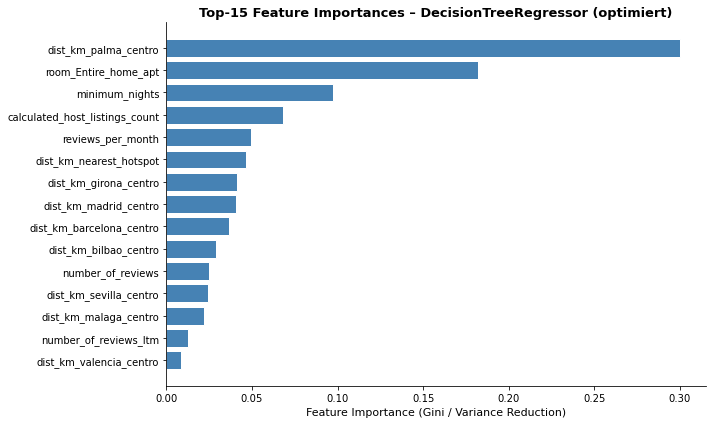

Plot gespeichert ✓


In [9]:
# ── Plot: Top-15 Feature Importance ────────────────────────────────────────
top15 = feat_imp_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top15['feature'][::-1],
    top15['importance'][::-1],
    color='steelblue', edgecolor='white'
)
ax.set_xlabel('Feature Importance (Gini / Variance Reduction)', fontsize=11)
ax.set_title(f'Top-15 Feature Importances – {model_III_name}', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}40_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot gespeichert ✓')

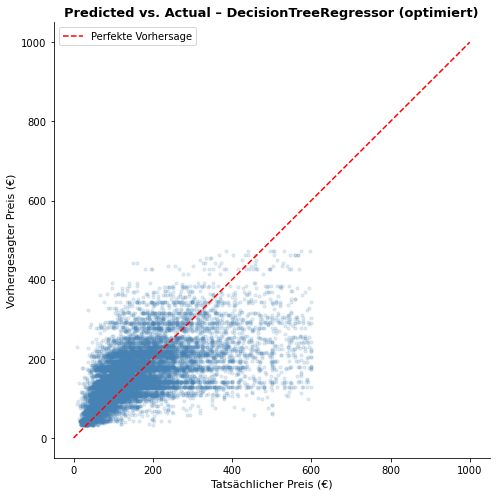

Plot gespeichert ✓


In [10]:
# ── Plot: Predicted vs. Actual ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_final, alpha=0.15, s=10, color='steelblue')
ax.plot([0, 1000], [0, 1000], 'r--', linewidth=1.5, label='Perfekte Vorhersage')
ax.set_xlabel('Tatsächlicher Preis (€)', fontsize=11)
ax.set_ylabel('Vorhergesagter Preis (€)', fontsize=11)
ax.set_title(f'Predicted vs. Actual – {model_III_name}', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}40_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot gespeichert ✓')

## 6 – Ergebnisse & Modell speichern (für Notebook 50)

In [11]:
# ── Metriken als CSV speichern ───────────────────────────────────────────────
metrics_model_III = pd.DataFrame([{
    'model':      model_III_name,
    'notebook':   '40',
    'mae':        round(mae_final, 4),
    'rmse':       round(rmse_final, 4),
    'r2':         round(r2_final, 4),
    'best_params': str(grid_search.best_params_ if not USE_FALLBACK else gb_grid.best_params_)
}])

metrics_model_III.to_csv(f'{CACHE_DIR}40_metrics_model_III.csv', index=False)
print('Metriken gespeichert:')
print(metrics_model_III.to_string(index=False))

# ── Modell als Pickle speichern ──────────────────────────────────────────────
with open(f'{CACHE_DIR}40_model_III.pkl', 'wb') as f:
    pickle.dump(best_model_III, f)
print(f'\nModell gespeichert → {CACHE_DIR}40_model_III.pkl')

# ── Feature-Namen speichern ───────────────────────────────────────────────────
pd.Series(FEATURE_NAMES).to_csv(f'{CACHE_DIR}40_feature_names.csv', index=False, header=['feature'])
print(f'Feature-Namen gespeichert → {CACHE_DIR}40_feature_names.csv')

Metriken gespeichert:
                            model notebook     mae    rmse     r2                                                                              best_params
DecisionTreeRegressor (optimiert)       40 56.6381 83.5769 0.3701 {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 50}

Modell gespeichert → cache/40_model_III.pkl
Feature-Namen gespeichert → cache/40_feature_names.csv


## 7 – Zusammenfassung

> Die folgende Zelle gibt eine saubere Zusammenfassung aus, die direkt
> in Notebook 50 als Grundlage für den Modellvergleich dient.

In [12]:
print('=' * 55)
print('  NOTEBOOK 40 – ZUSAMMENFASSUNG')
print('=' * 55)
print(f'  Modell III:  {model_III_name}')
print(f'  Features:    {len(FEATURE_NAMES)}')
print(f'  Train/Test:  {X_train.shape[0]:,} / {X_test.shape[0]:,} Samples')
print()
print(f'  MAE:         {mae_final:.2f} €')
print(f'  RMSE:        {rmse_final:.2f} €')
print(f'  R²:          {r2_final:.4f}')
print()
print('  Outputs:')
print(f'    cache/40_metrics_model_III.csv')
print(f'    cache/40_feature_importance.csv')
print(f'    cache/40_model_III.pkl')
print(f'    outputs/40_feature_importance.png')
print(f'    outputs/40_predicted_vs_actual.png')
print('=' * 55)

# ── TODO-Hinweise für Notebook 50 ──────────────────────────────────────────
print()
print('TODO für Notebook 50:')
print('  [ ] MAE, RMSE, R² von Modell I (Annika) manuell eintragen')
print('  [ ] MAE, RMSE, R² von Modell II (Mareike) manuell eintragen')
print('  [ ] Metriken-CSV von Modell I & II liegen vor? → einlesen')

  NOTEBOOK 40 – ZUSAMMENFASSUNG
  Modell III:  DecisionTreeRegressor (optimiert)
  Features:    21
  Train/Test:  63,844 / 15,962 Samples

  MAE:         56.64 €
  RMSE:        83.58 €
  R²:          0.3701

  Outputs:
    cache/40_metrics_model_III.csv
    cache/40_feature_importance.csv
    cache/40_model_III.pkl
    outputs/40_feature_importance.png
    outputs/40_predicted_vs_actual.png

TODO für Notebook 50:
  [ ] MAE, RMSE, R² von Modell I (Annika) manuell eintragen
  [ ] MAE, RMSE, R² von Modell II (Mareike) manuell eintragen
  [ ] Metriken-CSV von Modell I & II liegen vor? → einlesen


---
## Pipeline-Übersicht

```
Notebook 10  →  listings_spanien_cleaned.csv     (Annika: Datenbereinigung)
     ↓
Notebook 30  →  cache/20_features_engineered.csv (Mareike: EDA + Feature Engineering)
     ↓
Notebook 25  →  Modell I: Polynomiale Regression (Annika)
Notebook 35  →  Modell II: Random Forest         (Mareike)
Notebook 40  →  Modell III: Decision Tree        (Jasmin)  ← dieses Notebook
     ↓
Notebook 50  →  Modellvergleich & Business Insights (Jasmin)
```

Alle drei Modelle (25, 35, 40) laden denselben Feature-Datensatz aus `cache/20_features_engineered.csv`,
was einen direkten und fairen Vergleich in Notebook 50 ermöglicht.